# Generalized Linear Models (GLM) and Advanced Techniques

## 📌 What is a GLM?

A **Generalized Linear Model (GLM)** is an extension of linear regression that allows the response variable $Y$ to have **different distributions**, not just normal.  

GLMs consist of three components:

1. **Random Component**: $Y_i$ follows a distribution from the **exponential family** (e.g., Normal, Binomial, Poisson)  
2. **Systematic Component**: Linear predictor 
   $$
   \eta_i = \beta_0 + \beta_1 x_{i1} + ... + \beta_p x_{ip}
   $$  
3. **Link Function** $g(\cdot)$: connects expected value to linear predictor  
   $$
   g(\mathbb{E}[Y_i]) = \eta_i
   $$


## 📌 Common GLM Families and Link Functions

| Family      | Response Type       | Link Function       |
|------------|------------------|------------------|
| Gaussian   | Continuous         | Identity          |
| Binomial   | Binary (0/1)       | Logit             |
| Poisson    | Count data          | Log               |
| Gamma      | Positive continuous | Inverse           |

- Example: Logistic regression is a **GLM with binomial family** and logit link.
- Poisson regression is used for **count data** (e.g., number of accidents per day).


## 📌 GLM Formulation

For observation $i$:

$$
Y_i \sim \text{ExponentialFamily}(\mu_i, \phi)
$$

Linear predictor:  
$$
\eta_i = \beta_0 + \sum_{j=1}^{p} \beta_j x_{ij}
$$

Link function:  
$$
g(\mu_i) = \eta_i
$$

- $\mu_i = \mathbb{E}[Y_i]$  
- $\phi$ = dispersion parameter (for some distributions)  
- Coefficients $\beta_j$ estimated via **Maximum Likelihood Estimation (MLE)**


In [1]:
# Example: Predict number of daily emails received based on work hours
set.seed(123)
work_hours <- c(4, 5, 6, 7, 8, 9, 10)
emails_received <- c(1, 2, 3, 4, 5, 6, 8)  # count data

# Create data frame
glm_data <- data.frame(Hours = work_hours, Emails = emails_received)

# Fit Poisson regression (count data)
poisson_model <- glm(Emails ~ Hours, data = glm_data, family = poisson)

# Print summary
summary(poisson_model)

# Predicted values
glm_data$Predicted_Emails <- predict(poisson_model, type = "response")
print("Predicted Number of Emails:")
print(glm_data$Predicted_Emails)



Call:
glm(formula = Emails ~ Hours, family = poisson, data = glm_data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)   
(Intercept)  -0.7296     0.8454  -0.863  0.38809   
Hours         0.2848     0.1022   2.787  0.00532 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 8.88081  on 6  degrees of freedom
Residual deviance: 0.33278  on 5  degrees of freedom
AIC: 26.28

Number of Fisher Scoring iterations: 4


[1] "Predicted Number of Emails:"


[1] 1.506451 2.002904 2.662962 3.540543 4.707331 6.258636 8.321174


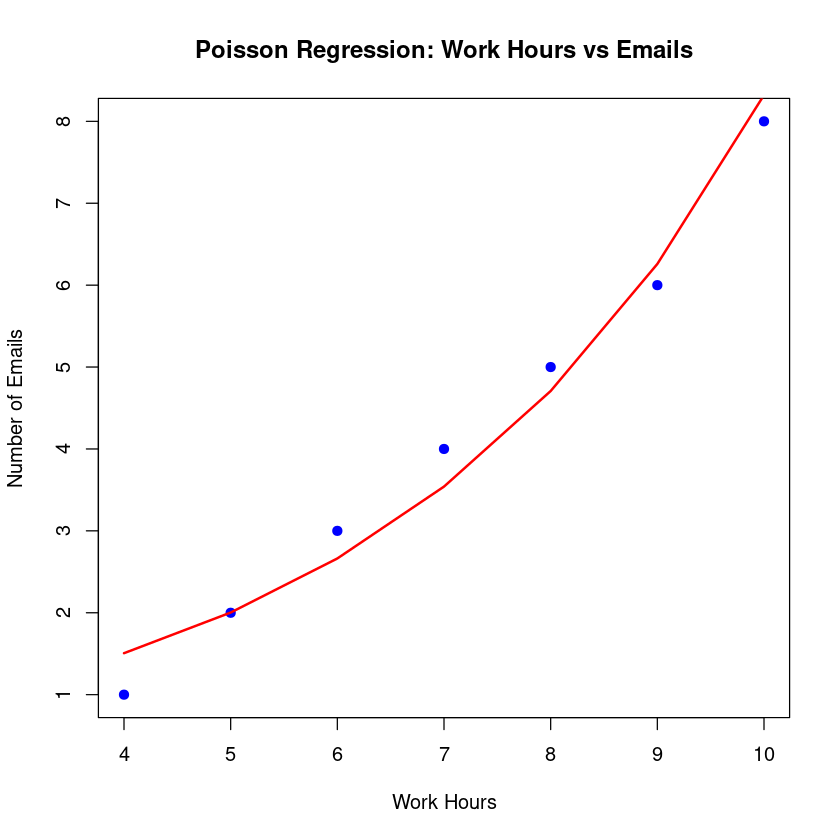

In [2]:
# Plot observed counts and predicted Poisson regression
plot(glm_data$Hours, glm_data$Emails, pch=19, col="blue",
     xlab="Work Hours", ylab="Number of Emails",
     main="Poisson Regression: Work Hours vs Emails")
lines(glm_data$Hours, glm_data$Predicted_Emails, col="red", lwd=2)


## 📌 Advanced Techniques in GLMs

1. **Overdispersion**: When variance > mean in count data (Poisson assumption violated)  
   - Use **Quasi-Poisson** or **Negative Binomial regression**

2. **Regularization**: Prevent overfitting with many predictors  
   - **Lasso (L1)**, **Ridge (L2)**, **Elastic Net**

3. **Interaction terms**: Model combined effect of predictors  
   $$
   \eta = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_1 X_2
   $$

4. **Model diagnostics**: Check residuals, leverage, influence points

5. **GLM extensions**: Mixed-effects models (GLMM), generalized additive models (GAM)


# Real-World Analogy

- **Poisson GLM**: Predicting number of cars passing a traffic light per hour based on time of day.  
- **Binomial GLM**: Predicting probability of a customer buying a product based on age and income.  
- GLMs allow **flexible modeling** for different types of outcomes beyond just continuous numbers.
